# XX — Choosing the embedding dimension

For every `d` in `DIMENSIONS`, a CWINDOW model is trained on each of the merged logs **BPIC11**,
**BPIC15** and **BPIC18**, and its total loss recorded. The logs are processed one after another and
the log is released before the next one is read, so only one of them is ever in memory.

Each log gets its own plot, on its own scale. Lower is a better fit; the dimension worth choosing is
where the curve flattens.


In [11]:
import gc
from pathlib import Path

import log_comparison_cwindow as lcw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from tqdm.auto import tqdm

SEED = 42

BASE_DIR = Path(lcw.__file__).resolve().parent
LOG_DIR = BASE_DIR / "logs"
OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def result_path(name):
    """One result file per log."""
    return OUT_DIR / f"XX_dimensions_{name}.csv"


LOGS = (
    "BPIC11",
    "BPIC15_M1_M2",
    "BPIC18_D4e_D6b",
)
COLOR = "#3B6EA5"

# True runs the sweeps and rewrites the result files, False just reloads them
RECOMPUTE_EMBEDDINGS = False

for n in LOGS:
    if RECOMPUTE_EMBEDDINGS:
        assert (LOG_DIR / f"{n}.xes").exists(), (
            f"missing log: {n} — run 00_preprocessing.ipynb"
        )
    else:
        assert result_path(n).exists(), (
            f"missing results: {result_path(n).name} — set RECOMPUTE_EMBEDDINGS = True"
        )

C = 4
UNIT_NORM = True  # keep the activity embeddings on the unit sphere, as 01_validity and
# 02_reliability do: each context embedding is L2-normalised before it enters the
# concatenated context vector, and the read-out is normalised too
LEARNING_RATE = 1e-2
EPOCHS = 2_000
DEVICE = "cpu"

DIMENSIONS = [2, 4, 8, 16, 32, 64, 128]
RUNS = 1


In [12]:
def sweep(name):
    """One log's dimension sweep. The event log is dropped as soon as it is encoded,
    and the traces as soon as the sweep is done, so the next log starts from a clean slate."""
    log = pm4py.read_xes(str(LOG_DIR / f"{name}.xes"), show_progress_bar=False)
    traces = lcw._convert_to_simpleEventLog(log)
    del log
    gc.collect()

    rows = []
    for d in tqdm(DIMENSIONS, desc=name, leave=False):
        losses = []
        for r in range(RUNS):
            lcw.set_seed(SEED + r)
            _, loss = lcw._train_cwindow(
                traces,
                C,
                d,
                LEARNING_RATE,
                EPOCHS,
                unit_norm=UNIT_NORM,
                device=DEVICE,
                verbose=True,
            )
            losses.append(loss)
        rows.append(
            {
                "log": name,
                "dim": d,
                "loss": float(np.mean(losses)),
                "std": float(np.std(losses)),
            }
        )

    del traces
    gc.collect()
    return pd.DataFrame(rows)


In [13]:
if RECOMPUTE_EMBEDDINGS:
    results = []
    for name in LOGS:
        df = sweep(name)
        df.to_csv(result_path(name), index=False)
        print(f"results -> {result_path(name).name}")
        results.append(df)
else:
    results = [pd.read_csv(result_path(name)) for name in LOGS]
    print(f"loaded {len(results)} cached result files")

dimensions = pd.concat(results, ignore_index=True)
dimensions


loaded 3 cached result files


,log,dim,loss,std
0,BPIC11,2,2.849254e+05,0.0
1,BPIC11,4,2.194163e+05,0.0
2,BPIC11,8,1.855728e+05,0.0
3,BPIC11,16,1.673567e+05,0.0
4,BPIC11,32,1.560360e+05,0.0
5,BPIC11,64,1.524367e+05,0.0
6,BPIC11,128,1.523818e+05,0.0
7,BPIC15_M1_M2,2,2.667158e+05,0.0
8,BPIC15_M1_M2,4,2.095618e+05,0.0
9,BPIC15_M1_M2,8,1.703897e+05,0.0


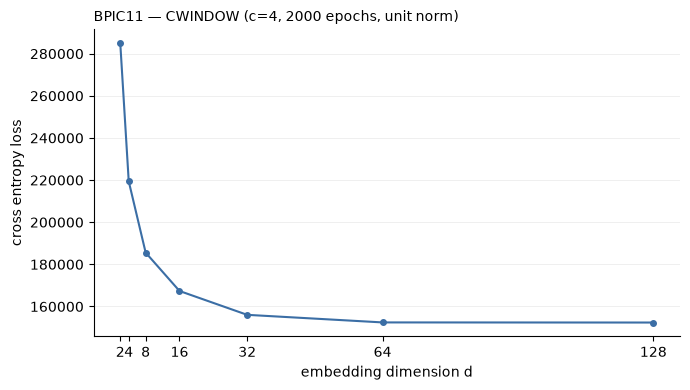

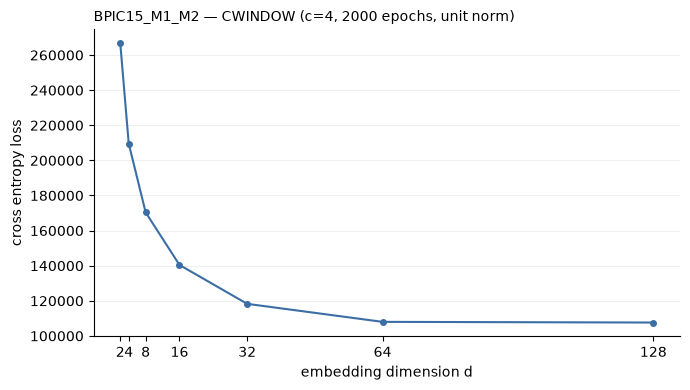

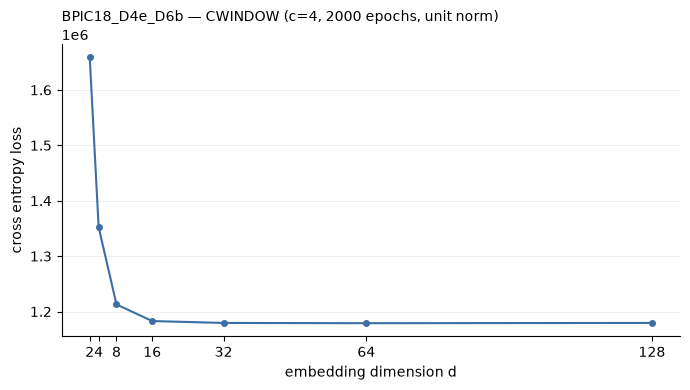

In [14]:
for name in LOGS:
    sub = dimensions[dimensions["log"] == name]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.35)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    ax.fill_between(
        sub["dim"],
        sub["loss"] - sub["std"],
        sub["loss"] + sub["std"],
        alpha=0.2,
        linewidth=0,
        color=COLOR,
    )
    ax.plot(sub["dim"], sub["loss"], marker="o", markersize=4, color=COLOR)
    ax.set_xticks(sub["dim"])
    ax.set_xlabel("embedding dimension d")
    ax.set_ylabel("cross entropy loss")
    ax.set_title(
        f"{name} — CWINDOW (c={C}, {EPOCHS} epochs"
        + (", unit norm" if UNIT_NORM else "")
        + ")",
        loc="left",
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()
